# Tóm tắt kết quả Desand và Detection (RBCP)

In [18]:
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import yaml
import sys
import dataclasses
sys.path.append('A:/HUST_on_GitHub/ProjectCV')

from ultralytics import YOLO
from src.restoration.registry import create_filter

## 1. Tải các cấu hình và mô hình YOLO

In [19]:
configs_paths = {
    "Default": "A:/HUST_on_GitHub/ProjectCV/configs/desand_rbcp_default.yaml",
    "Optuna_BRISQUE": "A:/HUST_on_GitHub/ProjectCV/configs/desand_optuna_config2_brisque.yaml",
    "Optuna_mAP50": "A:/HUST_on_GitHub/ProjectCV/configs/desand_optuna_config3_map50.yaml"
}

filters = {}
for name, path in configs_paths.items():
    if os.path.exists(path):
        filters[name] = create_filter("desand", path)
    else:
        print(f"Warning: {path} not found.")

yolo_model = YOLO('A:/HUST_on_GitHub/ProjectCV/yolo26n.pt')

In [20]:
def draw_gt_boxes(img, label_path):
    img_copy = img.copy()
    if not os.path.exists(label_path):
        return img_copy
        
    CLASS_NAMES = {
        0: "person",
        1: "bicycle",
        2: "car",
        3: "motorcycle",
        4: "airplane",
        5: "bus",
        6: "train",
        7: "truck"
    }

    h, w = img_copy.shape[:2]
    with open(label_path, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 5:
            cls_id = int(parts[0])
            cls_name = CLASS_NAMES.get(cls_id, str(cls_id))
            
            x_center = float(parts[1]) * w
            y_center = float(parts[2]) * h
            box_w = float(parts[3]) * w
            box_h = float(parts[4]) * h
            
            x1 = int(x_center - box_w / 2)
            y1 = int(y_center - box_h / 2)
            x2 = int(x_center + box_w / 2)
            y2 = int(y_center + box_h / 2)
            
            cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 3)
            cv2.putText(img_copy, f"GT: {cls_name}", (x1, max(y1 - 5, 0)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            
    return img_copy

def show_images_yolo(imgs, titles, figsize=(25, 5)):
    fig, axes = plt.subplots(1, len(imgs), figsize=figsize)
    if len(imgs) == 1: axes = [axes]
    for ax, img, title in zip(axes, imgs, titles):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=14, pad=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## 2. Bảng kết quả Metrics (Final Evaluation)

In [23]:
from IPython.display import display

print("=== NO-REFERENCE METRICS (BRISQUE, NIQE, PIQE, Entropy) ===")
eval_nr_csv = 'A:/HUST_on_GitHub/ProjectCV/results/sand_metrics/desand_no_reference_metrics.csv'
if os.path.exists(eval_nr_csv):
    df_nr = pd.read_csv(eval_nr_csv)
    display(df_nr)
else:
    print(f"Chưa có file kết quả {eval_nr_csv}")

print("\n=== DETECTION METRICS (mAP, Precision, Recall, Mean IoU) ===")
eval_det_csv = 'A:/HUST_on_GitHub/ProjectCV/results/sand_metrics/desand_detection_metrics.csv'
if os.path.exists(eval_det_csv):
    df_det = pd.read_csv(eval_det_csv)
    display(df_det)
else:
    print(f"Chưa có file kết quả {eval_det_csv}")

=== NO-REFERENCE METRICS (BRISQUE, NIQE, PIQE, Entropy) ===


,Method,BRISQUE,NIQE,PIQE,Entropy
0,Raw,47.997382,6.143000,52.667884,6.579937
1,RBCP_Default,39.915604,5.151701,48.230764,6.336737
2,Desand-config2-BRISQUE,37.283976,4.646992,46.701699,6.927477
3,Desand-config3-mAP50,40.598288,4.910196,47.456344,6.723707



=== DETECTION METRICS (mAP, Precision, Recall, Mean IoU) ===


,Method,map50,map50_95,mean_iou,precision,recall,f1,ap_person,ap_bicycle,ap_car,ap_motorcycle,ap_bus,ap_truck
0,Raw,0.445415,0.298487,0.454473,0.669927,0.394805,0.496821,0.606454,0.296031,0.713777,0.475655,0.334537,0.246037
1,RBCP_Default,0.429412,0.279391,0.473179,0.544777,0.387897,0.453143,0.618677,0.169298,0.714956,0.476658,0.350896,0.245985
2,Desand-config2-BRISQUE,0.461784,0.308193,0.492483,0.632701,0.383539,0.477575,0.649060,0.261427,0.746293,0.465578,0.401610,0.246738
3,Desand-config3-mAP50,0.429041,0.277375,0.474574,0.546071,0.410942,0.468966,0.657521,0.177172,0.732083,0.410290,0.367651,0.229527


## 3. Trực quan hóa kết quả (DAWN Sand)
So sánh Gốc vs Ground Truth vs Default vs Optuna Configs


--- Visualization: dusttornado-001.jpg ---


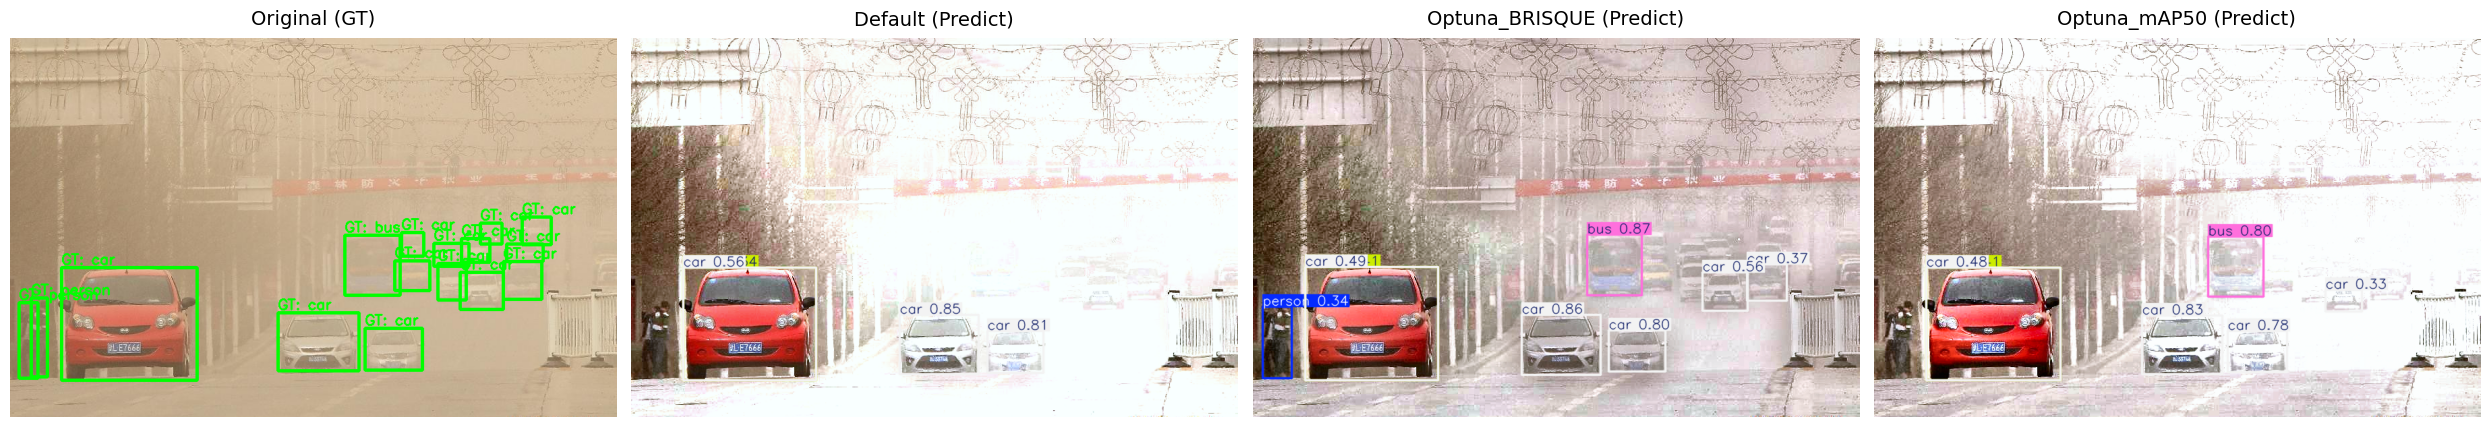


--- Visualization: dusttornado-002.jpg ---


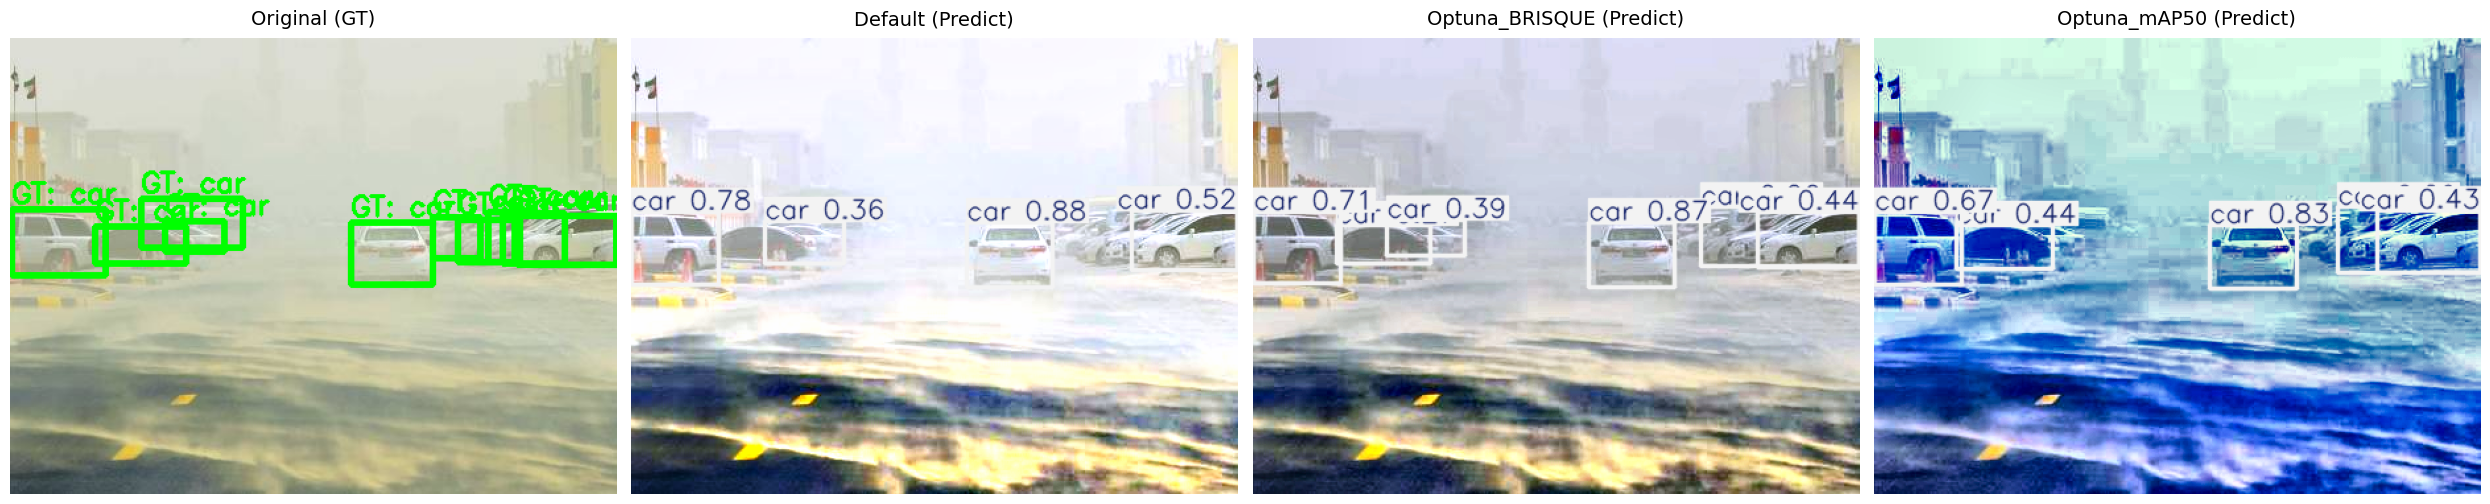


--- Visualization: dusttornado-003.jpg ---


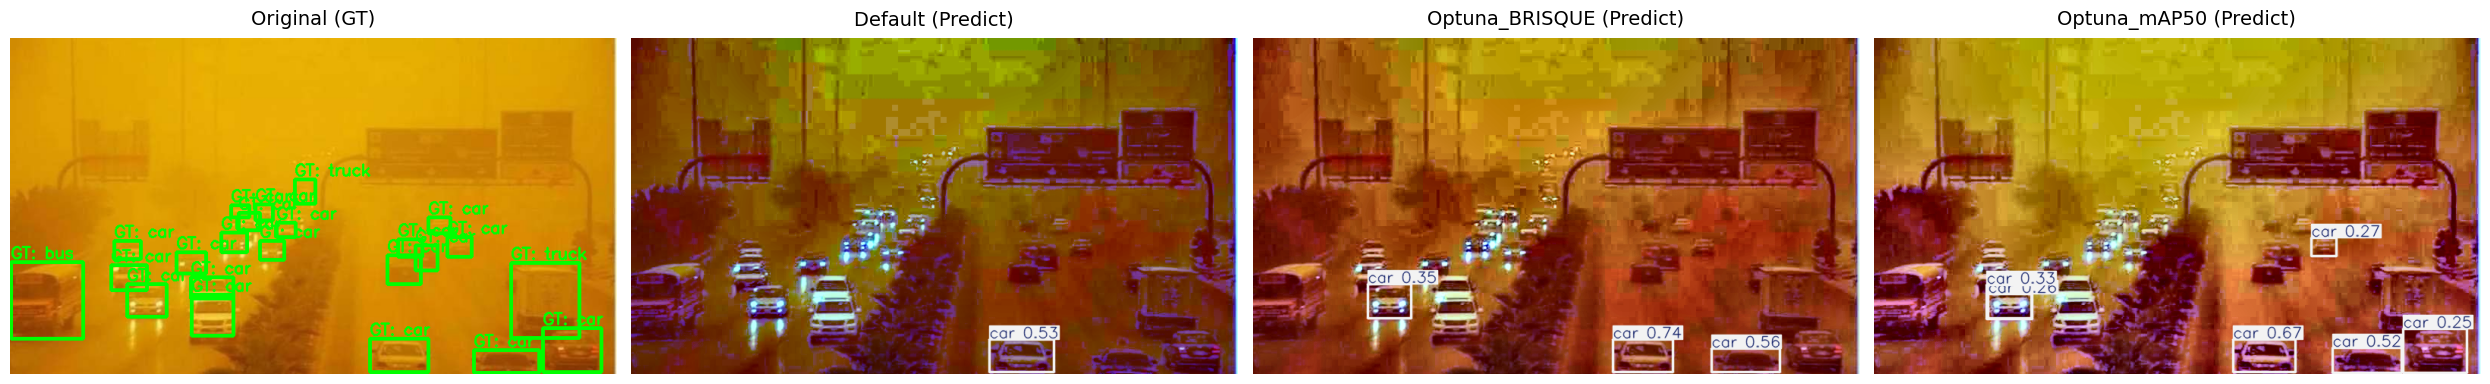


--- Visualization: dusttornado-004.jpg ---


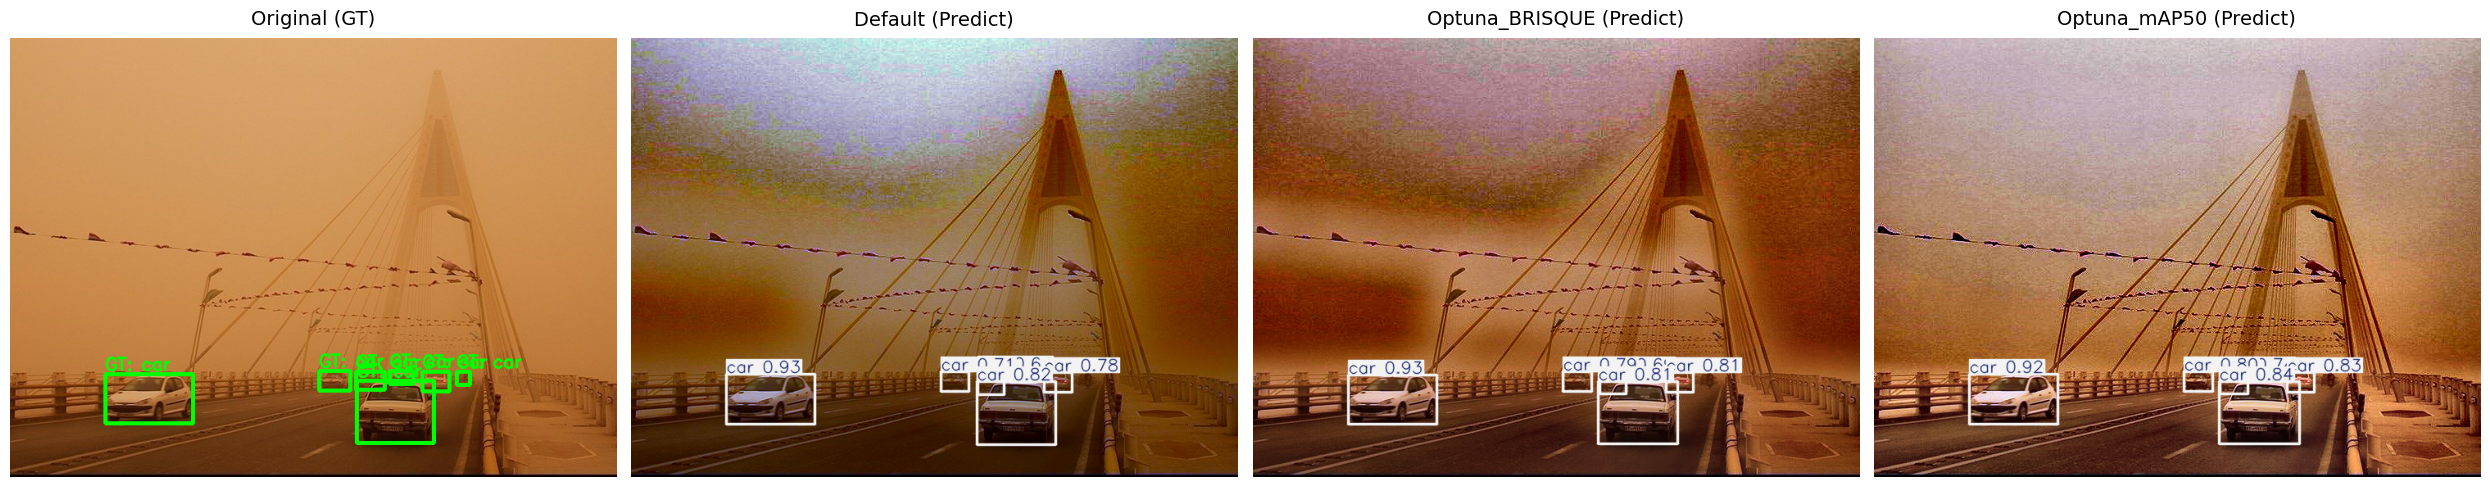


--- Visualization: dusttornado-005.jpg ---


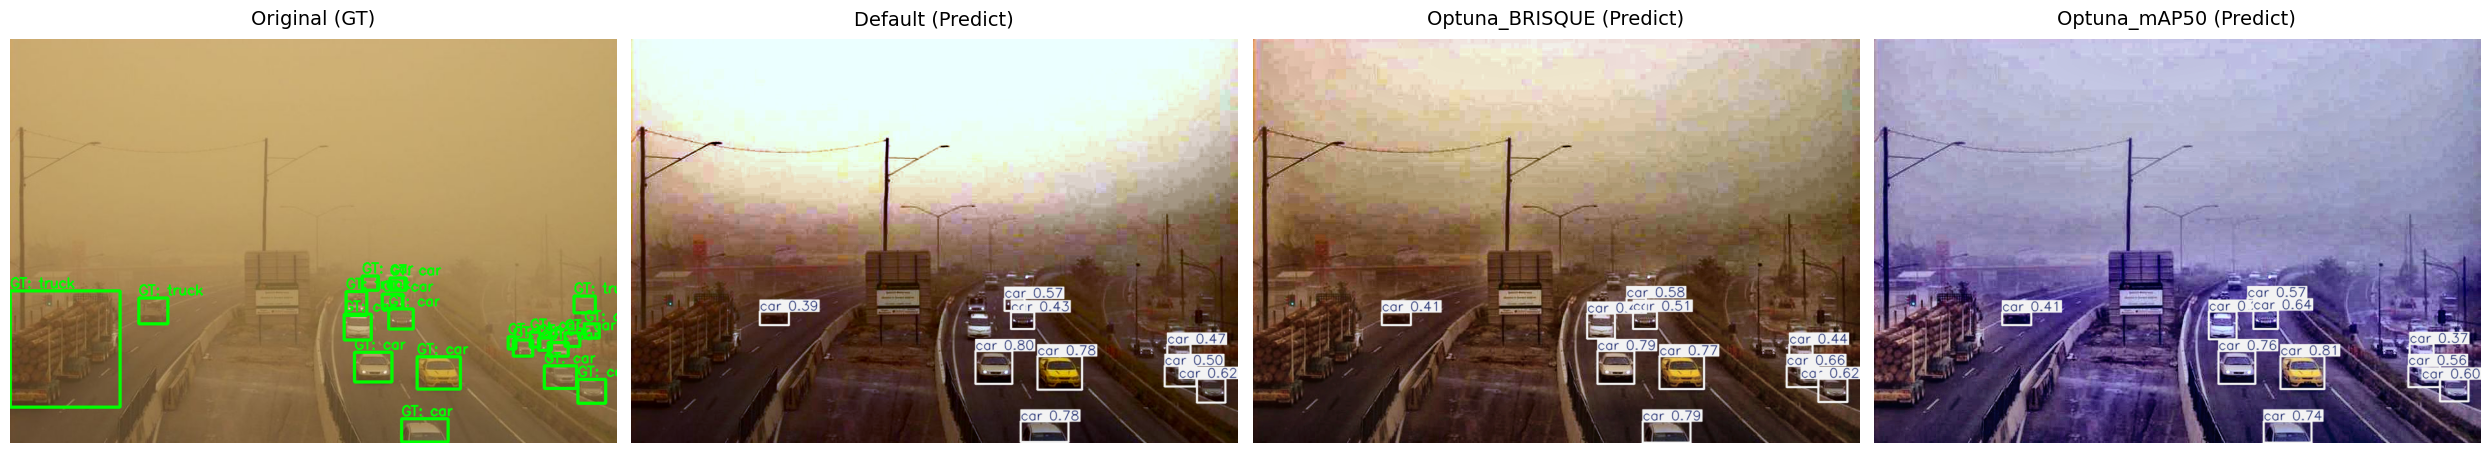

In [24]:
import glob

# Lấy một số ảnh mẫu từ DAWN Sand
sample_dir = "A:/HUST_on_GitHub/ProjectCV/data/dawn/images/sand"
sample_images = glob.glob(os.path.join(sample_dir, "*.jpg"))[:5]

for img_path in sample_images:
    img_name = os.path.basename(img_path)
    print(f"\n{'='*50}\n--- Visualization: {img_name} ---")
    
    img_bgr = cv2.imread(img_path)
    label_path = img_path.replace("images", "labels_yolo").replace(".jpg", ".txt")
    
    # Tạo ảnh Ground Truth
    img_gt_bgr = draw_gt_boxes(img_bgr, label_path)
    
    # Chuẩn bị ảnh
    restored_imgs = {"Original (GT)": img_gt_bgr}
    for name, f in filters.items():
        restored_imgs[name] = f.restore(img_bgr)
        
    imgs_to_show = []
    titles_to_show = []
    
    # Inference YOLO
    for name, r_img in restored_imgs.items():
        if name == "Original (GT)":
            imgs_to_show.append(r_img)
            titles_to_show.append(name)
        else:
            results = yolo_model.predict(r_img, verbose=False, classes=[0, 1, 2, 3, 5, 6, 7])
            annotated_img_bgr = results[0].plot()
            imgs_to_show.append(annotated_img_bgr)
            titles_to_show.append(f"{name} (Predict)")
            
    show_images_yolo(imgs_to_show, titles_to_show, figsize=(25, 5))